# Adversarial Attacks on MNIST CNN

This notebook trains a CNN on MNIST, then attacks it with three white-box adversarial methods:
1. **FGSM** (Fast Gradient Sign Method)
2. **I-FGSM / PGD** (Iterative FGSM / Projected Gradient Descent)
3. **MI-FGSM** (Momentum Iterative FGSM)

Metrics reported: **recognition rate** (clean accuracy) and **attack success rate (ASR)**.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")
torch.manual_seed(42)

Using device: mps


## CNN Architecture

Same architecture that achieved **99.08%** test accuracy in Module 4.

In [2]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Load MNIST Data

In [3]:
BATCH_SIZE = 128
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.91MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 305kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.28MB/s]

Train samples: 60000
Test samples:  10000


## Train CNN

Best config from Module 4: **Adam, lr=1e-3, 10 epochs**.

In [4]:
EPOCHS = 10
LR = 1e-3
CKPT_DIR = "checkpoints"
CKPT_PATH = os.path.join(CKPT_DIR, "cnn_best.pt")


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return correct / total


os.makedirs(CKPT_DIR, exist_ok=True)

if os.path.exists(CKPT_PATH):
    print(f"Checkpoint found at {CKPT_PATH}, skipping training.")
else:
    model = CNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        test_acc = evaluate(model, test_loader)
        print(f"Epoch {epoch:2d}/{EPOCHS}  "
              f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  "
              f"Test Acc: {test_acc*100:.2f}%")

    torch.save(model.state_dict(), CKPT_PATH)
    print(f"\nCheckpoint saved to {CKPT_PATH}")

Epoch  1/10  Train Loss: 0.2219  Train Acc: 93.44%  Test Acc: 97.69%
Epoch  2/10  Train Loss: 0.0599  Train Acc: 98.16%  Test Acc: 98.69%
Epoch  3/10  Train Loss: 0.0425  Train Acc: 98.71%  Test Acc: 98.78%
Epoch  4/10  Train Loss: 0.0328  Train Acc: 98.96%  Test Acc: 98.70%
Epoch  5/10  Train Loss: 0.0255  Train Acc: 99.19%  Test Acc: 98.83%
Epoch  6/10  Train Loss: 0.0195  Train Acc: 99.37%  Test Acc: 98.76%
Epoch  7/10  Train Loss: 0.0169  Train Acc: 99.44%  Test Acc: 98.72%
Epoch  8/10  Train Loss: 0.0120  Train Acc: 99.63%  Test Acc: 98.57%
Epoch  9/10  Train Loss: 0.0116  Train Acc: 99.64%  Test Acc: 99.03%
Epoch 10/10  Train Loss: 0.0105  Train Acc: 99.65%  Test Acc: 98.95%

Checkpoint saved to checkpoints/cnn_best.pt


## Load Checkpoint and Verify Clean Accuracy

In [5]:
model = CNN().to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device, weights_only=True))
model.eval()

clean_acc = evaluate(model, test_loader)
print(f"Clean test accuracy (recognition rate): {clean_acc*100:.2f}%")

Clean test accuracy (recognition rate): 98.95%


## Attack Helpers

Since images are normalized, the valid pixel range in normalized space is:
- min: `(0 - mean) / std`
- max: `(1 - mean) / std`

**Attack Success Rate (ASR):** fraction of originally-correct predictions that flip after perturbation.

In [6]:
NORM_MIN = (0.0 - MNIST_MEAN) / MNIST_STD
NORM_MAX = (1.0 - MNIST_MEAN) / MNIST_STD


def clamp_normalized(x):
    """Clamp tensor to the valid normalized pixel range."""
    return torch.clamp(x, NORM_MIN, NORM_MAX)


def compute_asr(model, test_loader, attack_fn, **attack_kwargs):
    """
    Run attack on the full test set and return:
      - clean_acc: accuracy on unperturbed images
      - asr: fraction of correctly-classified samples whose prediction flipped
    """
    model.eval()
    total_correct_clean = 0
    total_fooled = 0
    total = 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            clean_preds = model(images).argmax(1)
        correct_mask = clean_preds == labels

        adv_images = attack_fn(model, images, labels, **attack_kwargs)

        with torch.no_grad():
            adv_preds = model(adv_images).argmax(1)

        fooled = correct_mask & (adv_preds != labels)

        total_correct_clean += correct_mask.sum().item()
        total_fooled += fooled.sum().item()
        total += images.size(0)

    clean_acc = total_correct_clean / total
    asr = total_fooled / total_correct_clean if total_correct_clean > 0 else 0.0
    return clean_acc, asr

## Attack 1: FGSM

Single-step attack:

$$x_{adv} = x + \varepsilon \cdot \text{sign}(\nabla_x L(\theta, x, y))$$

In [7]:
def fgsm_attack(model, images, labels, eps):
    images_adv = images.clone().detach().requires_grad_(True)
    outputs = model(images_adv)
    loss = nn.functional.cross_entropy(outputs, labels)
    loss.backward()

    perturbation = eps * images_adv.grad.sign()
    adv = clamp_normalized(images.detach() + perturbation)
    return adv.detach()

## Attack 2: I-FGSM / PGD

Iterative attack with L-inf projection:

$$x_{t+1} = \Pi_{\varepsilon}\!\big(x_t + \alpha \cdot \text{sign}(\nabla_x L(\theta, x_t, y))\big)$$

PGD variant adds a random start within the $\varepsilon$-ball.

In [8]:
def pgd_attack(model, images, labels, eps, alpha=None, num_iter=10, random_start=True):
    if alpha is None:
        alpha = eps / 4

    adv = images.clone().detach()

    if random_start:
        adv = adv + torch.empty_like(adv).uniform_(-eps, eps)
        adv = clamp_normalized(adv)

    for _ in range(num_iter):
        adv.requires_grad_(True)
        outputs = model(adv)
        loss = nn.functional.cross_entropy(outputs, labels)
        loss.backward()
        grad_sign = adv.grad.sign()
        adv = adv.detach() + alpha * grad_sign

        # Project back into eps-ball around original image
        delta = torch.clamp(adv - images, -eps, eps)
        adv = clamp_normalized(images + delta).detach()

    return adv

## Attack 3: Momentum I-FGSM (MI-FGSM)

Adds momentum to stabilize gradient direction across iterations (Dong et al., 2018):

$$g_{t+1} = \mu \cdot g_t + \frac{\nabla_x L(\theta, x_t, y)}{\|\nabla_x L(\theta, x_t, y)\|_1}$$
$$x_{t+1} = \Pi_{\varepsilon}\!\big(x_t + \alpha \cdot \text{sign}(g_{t+1})\big)$$

In [9]:
def mifgsm_attack(model, images, labels, eps, alpha=None, num_iter=10, mu=1.0):
    if alpha is None:
        alpha = eps / 4

    adv = images.clone().detach()
    momentum = torch.zeros_like(images)

    for _ in range(num_iter):
        adv.requires_grad_(True)
        outputs = model(adv)
        loss = nn.functional.cross_entropy(outputs, labels)
        loss.backward()

        grad = adv.grad
        grad_norm = grad / (grad.abs().mean(dim=[1, 2, 3], keepdim=True) + 1e-12)
        momentum = mu * momentum + grad_norm

        adv = adv.detach() + alpha * momentum.sign()

        delta = torch.clamp(adv - images, -eps, eps)
        adv = clamp_normalized(images + delta).detach()

    return adv

## Run All Attacks

Evaluate each attack across a range of epsilon values.

In [10]:
EPSILONS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

attacks = {
    "FGSM":    lambda m, x, y, eps: fgsm_attack(m, x, y, eps),
    "PGD":     lambda m, x, y, eps: pgd_attack(m, x, y, eps, num_iter=10),
    "MI-FGSM": lambda m, x, y, eps: mifgsm_attack(m, x, y, eps, num_iter=10, mu=1.0),
}

results = {name: {"eps": [], "asr": []} for name in attacks}

print(f"{'Attack':<10} {'Epsilon':>8} {'Clean Acc':>10} {'ASR':>8}")
print("-" * 40)

for eps in EPSILONS:
    for name, attack_fn in attacks.items():
        clean_acc, asr = compute_asr(
            model, test_loader, attack_fn, eps=eps
        )
        results[name]["eps"].append(eps)
        results[name]["asr"].append(asr)
        print(f"{name:<10} {eps:>8.2f} {clean_acc*100:>9.2f}% {asr*100:>7.2f}%")

Attack      Epsilon  Clean Acc      ASR
----------------------------------------
FGSM           0.05     98.95%    0.81%
PGD            0.05     98.95%    0.94%
MI-FGSM        0.05     98.95%    0.94%
FGSM           0.10     98.95%    2.07%
PGD            0.10     98.95%    2.62%
MI-FGSM        0.10     98.95%    2.68%
FGSM           0.15     98.95%    3.82%
PGD            0.15     98.95%    5.38%
MI-FGSM        0.15     98.95%    5.49%
FGSM           0.20     98.95%    6.40%
PGD            0.20     98.95%   10.66%
MI-FGSM        0.20     98.95%   10.77%
FGSM           0.25     98.95%   10.31%
PGD            0.25     98.95%   19.02%
MI-FGSM        0.25     98.95%   19.09%
FGSM           0.30     98.95%   15.27%
PGD            0.30     98.95%   30.85%
MI-FGSM        0.30     98.95%   30.75%


## ASR vs Epsilon

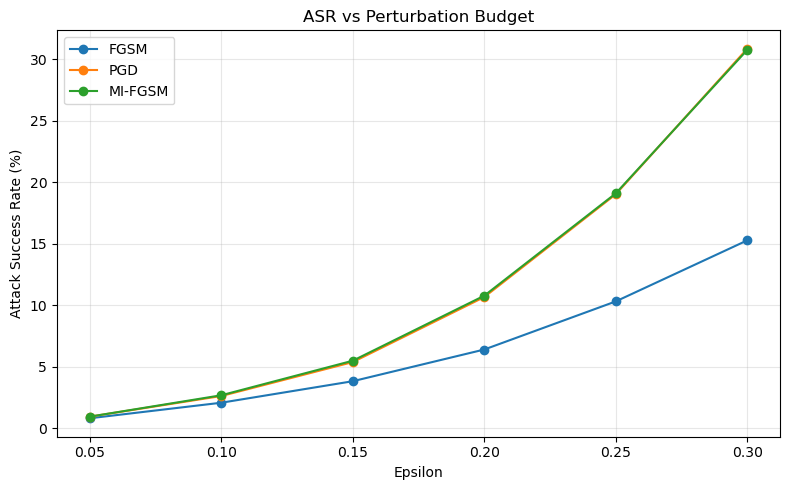

In [11]:
plt.figure(figsize=(8, 5))
for name, data in results.items():
    plt.plot(data["eps"], [a * 100 for a in data["asr"]], "o-", label=name)

plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate (%)")
plt.title("ASR vs Perturbation Budget")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("asr_vs_epsilon.png", dpi=150)
plt.show()

## Adversarial Examples Visualization

Show original images alongside adversarial examples from each attack at a fixed epsilon.

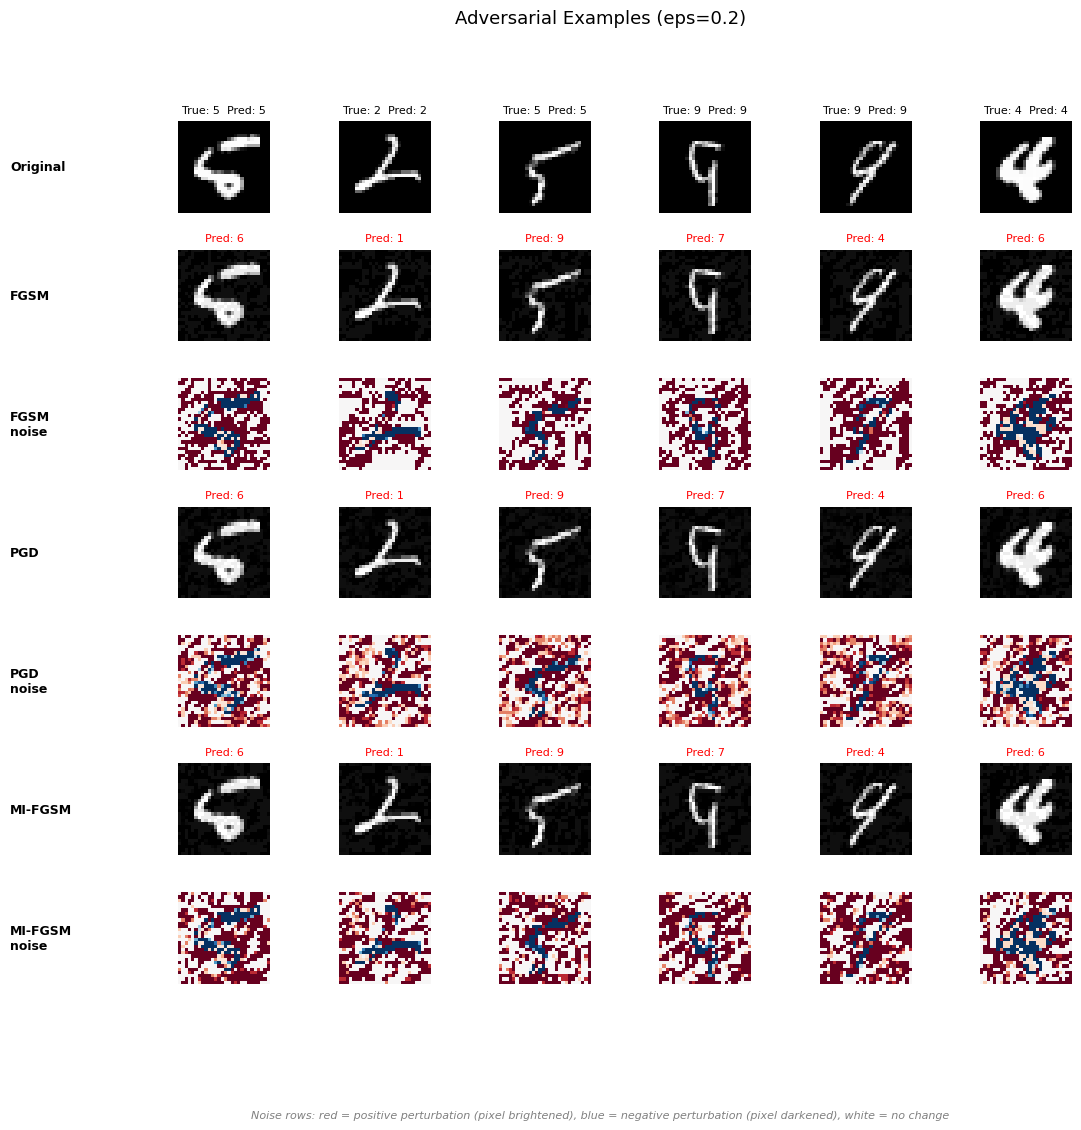

In [17]:
VIS_EPS = 0.2
NUM_EXAMPLES = 6


def denormalize(t):
    return (t * MNIST_STD + MNIST_MEAN).clamp(0, 1)


# Collect successfully-attacked examples (FGSM flipped the prediction)
vis_images, vis_labels = [], []
for batch_imgs, batch_lbls in test_loader:
    batch_imgs, batch_lbls = batch_imgs.to(device), batch_lbls.to(device)

    with torch.no_grad():
        clean_preds = model(batch_imgs).argmax(1)
    correct_mask = clean_preds == batch_lbls

    adv_batch = fgsm_attack(model, batch_imgs, batch_lbls, VIS_EPS)
    with torch.no_grad():
        adv_preds = model(adv_batch).argmax(1)
    fooled_mask = correct_mask & (adv_preds != batch_lbls)

    if fooled_mask.any():
        vis_images.append(batch_imgs[fooled_mask])
        vis_labels.append(batch_lbls[fooled_mask])
    if sum(v.size(0) for v in vis_images) >= NUM_EXAMPLES:
        break

images = torch.cat(vis_images)[:NUM_EXAMPLES]
labels = torch.cat(vis_labels)[:NUM_EXAMPLES]

adv_sets = {
    "FGSM":    fgsm_attack(model, images, labels, VIS_EPS),
    "PGD":     pgd_attack(model, images, labels, VIS_EPS, num_iter=10),
    "MI-FGSM": mifgsm_attack(model, images, labels, VIS_EPS, num_iter=10, mu=1.0),
}

row_labels = ["Original"]
for name in adv_sets:
    row_labels.append(name)
    row_labels.append(f"{name}\nnoise")

rows = len(row_labels)
fig, axes = plt.subplots(rows, NUM_EXAMPLES, figsize=(NUM_EXAMPLES * 1.8 + 1.5, rows * 1.6))
fig.subplots_adjust(left=0.14, hspace=0.4)

for j in range(NUM_EXAMPLES):
    img_np = denormalize(images[j]).cpu().squeeze().numpy()
    pred = model(images[j:j+1]).argmax(1).item()
    axes[0, j].imshow(img_np, cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"True: {labels[j].item()}  Pred: {pred}", fontsize=8)
    axes[0, j].axis("off")

row_idx = 1
for name, adv_imgs in adv_sets.items():
    delta = (adv_imgs - images).detach()
    for j in range(NUM_EXAMPLES):
        adv_np = denormalize(adv_imgs[j]).cpu().squeeze().numpy()
        pred = model(adv_imgs[j:j+1]).argmax(1).item()
        axes[row_idx, j].imshow(adv_np, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, j].set_title(f"Pred: {pred}", fontsize=8,
                                   color="red" if pred != labels[j].item() else "green")
        axes[row_idx, j].axis("off")

        delta_np = delta[j].cpu().squeeze().numpy()
        abs_max = max(abs(delta_np.min()), abs(delta_np.max()), 1e-8)
        axes[row_idx + 1, j].imshow(delta_np, cmap="RdBu_r", vmin=-abs_max, vmax=abs_max)
        axes[row_idx + 1, j].axis("off")

    row_idx += 2

for i, label in enumerate(row_labels):
    pos = axes[i, 0].get_position()
    fig.text(0.02, (pos.y0 + pos.y1) / 2, label,
             fontsize=9, fontweight="bold", va="center", ha="left")

fig.suptitle(f"Adversarial Examples (eps={VIS_EPS})", fontsize=13)
fig.text(0.5, -0.01,
         "Noise rows: red = positive perturbation (pixel brightened), "
         "blue = negative perturbation (pixel darkened), white = no change",
         fontsize=8, ha="center", style="italic", color="gray")
plt.savefig("adversarial_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary Table

In [13]:
print(f"\nClean test accuracy: {clean_acc*100:.2f}%\n")
print(f"{'Epsilon':<10}", end="")
for name in attacks:
    print(f"{name:>12}", end="")
print()
print("-" * (10 + 12 * len(attacks)))

for idx, eps in enumerate(EPSILONS):
    print(f"{eps:<10.2f}", end="")
    for name in attacks:
        print(f"{results[name]['asr'][idx]*100:>11.2f}%", end="")
    print()


Clean test accuracy: 98.95%

Epsilon           FGSM         PGD     MI-FGSM
----------------------------------------------
0.05             0.81%       0.94%       0.94%
0.10             2.07%       2.62%       2.68%
0.15             3.82%       5.38%       5.49%
0.20             6.40%      10.66%      10.77%
0.25            10.31%      19.02%      19.09%
0.30            15.27%      30.85%      30.75%
